In [51]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import pickle as pkl
import networkx as nx
import matplotlib.pyplot as plt
import pyomo.environ as pe


In [52]:

import visualizations as vis

import good
from good.reload import deep_reload

In [53]:
# Helper functions for EV load and graph manipulation
from copy import deepcopy

def generate_random_ev_load(num_hours=168, max_peak_gw=1.0, seed=None):
    """
    Generate randomized EV charging load profile.
    
    Parameters:
    -----------
    num_hours : int
        Number of hours (default 168 for 7 days)
    max_peak_gw : float
        Maximum peak load in GW (default 1.0 GW)
    seed : int, optional
        Random seed for reproducibility
        
    Returns:
    --------
    ev_load : np.array
        Array of EV charging load in Watts (not GW)
    """
    if seed is not None:
        np.random.seed(seed)
    
    # Generate random load profile with some daily patterns
    # Create a base pattern with higher loads during typical charging times
    hours = np.arange(num_hours)
    daily_pattern = np.sin(2 * np.pi * (hours % 24) / 24 - np.pi/2) + 1  # Higher in evening/night
    daily_pattern = daily_pattern / daily_pattern.max()  # Normalize to [0, 1]
    
    # Add randomness
    random_component = np.random.uniform(0.3, 1.0, num_hours)
    
    # Combine pattern with randomness
    ev_load_normalized = daily_pattern * random_component
    
    # Scale to max peak (in GW), then convert to Watts
    ev_load_gw = ev_load_normalized * max_peak_gw
    ev_load = ev_load_gw * 1e9  # Convert GW to Watts
    
    return ev_load

def slice_graph_profiles(graph, start_hour=0, num_hours=168):
    """
    Slice graph profiles to a specific time window.
    
    Parameters:
    -----------
    graph : networkx.DiGraph
        The graph to modify
    start_hour : int
        Start hour for slicing
    num_hours : int
        Duration in hours
        
    Returns:
    --------
    graph : networkx.DiGraph
        Modified graph with sliced profiles
    """
    graph = deepcopy(graph)
    
    for node_name, node_data in graph._node.items():
        # Slice profiles in node's profile dictionary
        if 'profiles' in node_data:
            for profile_name, profile_data in node_data['profiles'].items():
                if isinstance(profile_data, (list, np.ndarray)) and len(profile_data) > start_hour + num_hours:
                    node_data['profiles'][profile_name] = profile_data[start_hour:start_hour + num_hours]
        
        # Slice profiles in assets
        if 'assets' in node_data:
            for asset_name, asset_data in node_data['assets'].items():
                profile = asset_data.get('profile', None)
                if isinstance(profile, (list, np.ndarray)) and len(profile) > start_hour + num_hours:
                    asset_data['profile'] = profile[start_hour:start_hour + num_hours]
                elif isinstance(profile, str):
                    # Handle string references to profiles
                    if 'profiles' in node_data and profile in node_data['profiles']:
                        profile_data = node_data['profiles'][profile]
                        if isinstance(profile_data, (list, np.ndarray)) and len(profile_data) > start_hour + num_hours:
                            node_data['profiles'][profile] = profile_data[start_hour:start_hour + num_hours]
    
    return graph

def add_ev_charging_load(graph, ev_charging_load, start_hour=0, num_hours=168):
    """
    Add EV charging load to the graph.

    IMPORTANT:
    - This function **does not slice** the graph profiles.
    - GOOD's `Network` slices internally using `kw['steps']` (via `model.start`/`model.stop`).
      If you slice profiles here and also use absolute `steps`, you'll end up with empty slices.

    Parameters:
    -----------
    graph : networkx.DiGraph
        The graph to modify
    ev_charging_load : np.array
        Array of EV charging load in absolute Watts (length = num_hours)
    start_hour : int
        Start hour offset into existing profiles
    num_hours : int
        Duration in hours

    Returns:
    --------
    graph : networkx.DiGraph
        Modified graph
    """
    graph = deepcopy(graph)

    ev_charging_load = np.asarray(ev_charging_load)
    if len(ev_charging_load) != num_hours:
        raise ValueError(
            f"ev_charging_load length ({len(ev_charging_load)}) must equal num_hours ({num_hours})"
        )

    window_start = int(start_hour)
    window_stop = int(start_hour + num_hours)

    # Calculate total system base load for proportions
    total_base_load_system = 0
    node_base_loads = {}

    for node_name, node_data in graph._node.items():
        node_capacity = 0
        if 'assets' in node_data:
            for _, asset_data in node_data['assets'].items():
                if asset_data.get('_class') == 'Load':
                    node_capacity += abs(asset_data.get('installed_capacity', 0))

        if node_capacity > 0:
            node_base_loads[node_name] = node_capacity
            total_base_load_system += node_capacity

    if total_base_load_system == 0:
        raise ValueError("No load assets found in graph to attach EV load to!")

    # Distribute EV load to nodes & assets
    for node_name, node_data in graph._node.items():
        if node_name not in node_base_loads:
            continue

        node_proportion = node_base_loads[node_name] / total_base_load_system
        ev_load_profile_for_node = ev_charging_load * node_proportion

        load_assets = {
            k: v for k, v in node_data.get('assets', {}).items()
            if v.get('_class') == 'Load'
        }

        total_capacity_in_node = sum(abs(a.get('installed_capacity', 0)) for a in load_assets.values())

        for _, asset_data in load_assets.items():
            asset_capacity_abs = abs(asset_data.get('installed_capacity', 0))
            asset_share = (asset_capacity_abs / total_capacity_in_node) if total_capacity_in_node > 0 else 0
            ev_load_for_asset = ev_load_profile_for_node * asset_share

            existing_profile = asset_data.get('profile', None)

            if isinstance(existing_profile, str):
                shared_name = existing_profile
                existing_profile_data = node_data.get('profiles', {}).get(shared_name)
                if existing_profile_data is None:
                    raise ValueError(
                        f"Profile '{shared_name}' not found in node '{node_name}' profiles"
                    )

                base = np.asarray(existing_profile_data, dtype=float)
                if len(base) < window_stop:
                    raise ValueError(
                        f"Profile '{shared_name}' in node '{node_name}' has length {len(base)}, "
                        f"but needs at least {window_stop} to add EV load at [{window_start}:{window_stop})"
                    )

                base[window_start:window_stop] = base[window_start:window_stop] + ev_load_for_asset
                node_data.setdefault('profiles', {})[shared_name] = base.tolist()

            elif isinstance(existing_profile, (list, np.ndarray)):
                base = np.asarray(existing_profile, dtype=float)
                if len(base) < window_stop:
                    raise ValueError(
                        f"Asset profile in node '{node_name}' has length {len(base)}, "
                        f"but needs at least {window_stop} to add EV load at [{window_start}:{window_stop})"
                    )

                base[window_start:window_stop] = base[window_start:window_stop] + ev_load_for_asset
                asset_data['profile'] = base.tolist()

            else:
                # No existing profile: create a zero profile long enough for the window
                base = np.zeros(window_stop, dtype=float)
                base[window_start:window_stop] = ev_load_for_asset
                asset_data['profile'] = base.tolist()

    return graph

def normalize_graph(graph):
    """
    Normalize graph profiles to ensure unit consistency.
    This is a placeholder - adjust based on your graph structure.
    """
    # Add normalization logic if needed
    pass

This nodebook shows an example of how to run GOOD for a pre-built graph. In this case the aggregated California example graph is loaded and run for 7 days with results plotted. The same is done with flexible base loads in the second example.

The first step is to load the graph. Let's use the WECC example.

In [54]:
deep_reload(good)
graph = good.graph.graph_from_json('Examples/California.json')

graph.nodes

NodeView(('WEC_BANC', 'WEC_CALN', 'WEC_LADW', 'WEC_SDGE', 'WECC_IID', 'WECC_SCE'))

This notebook runs two scenarios for 7 days (168 hours):
1. **Baseline scenario**: Base load only
2. **EV scenario**: Base load + randomized EV charging load (max 1GW)

We'll compare the results from both scenarios.


In [55]:
'''
Loading graph and policies
'''
deep_reload(good)

graph = good.graph.graph_from_json('Examples/California.json')

policies = good.utilities.read_json('Examples/policies.json')

In [56]:
'''
Building from graph for 7 day run - 06/01:00:00:00 - 06/07:23:59:59
'''
deep_reload(good)

kw = {
    'verbose': True,
    'steps': (6 * 32 * 24, 6 * 32 * 24 + 24 * 7),
    'amortization_period': 31536000,
    'shortfall_capacity': np.inf,
    'shortfall_cost': 1e3,
    'wastage_capacity': np.inf,
    'wastage_cost': 1e3,
}

network = good.optimization.network.Network(**kw).from_graph(
    graph, policies)

'''
Building the model
'''

network.build()

'''
Printing model size report
'''

network.size()

Parameters Built: 1.9337520599365234
Variables Built: 0.3999159336090088
Constraints Built: 6.006691217422485
Objective Built: 0.147475004196167


ModelSizeReport(activated = Bunch(binary_variables = 0, constraints = 201520, continuous_variables = 74292, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 74292), overall = Bunch(binary_variables = 0, constraints = 201520, continuous_variables = 74292, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 74292), warning = Bunch(unassociated_disjuncts = 0))

In [57]:
'''
Solve both scenarios
'''
deep_reload(good)

# -----------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------
NUM_HOURS = 168  # 7 days
START_HOUR = 6 * 32 * 24  # Start from June 1st

# Ensure kw exists and is consistent with GOOD's internal slicing.
# (GOOD slices profile arrays using model.start/model.stop, so we must NOT pre-slice profiles.)
try:
    kw
except NameError:
    kw = {
        'verbose': True,
        'steps': (START_HOUR, START_HOUR + NUM_HOURS),
        'amortization_period': 31536000,
        'shortfall_capacity': np.inf,
        'shortfall_cost': 1e3,
        'wastage_capacity': np.inf,
        'wastage_cost': 1e3,
    }

# Generate randomized EV load (max 1GW) if not already set
try:
    ev_charging_load
except NameError:
    ev_charging_load = generate_random_ev_load(num_hours=NUM_HOURS, max_peak_gw=1.0, seed=42)

solver_kw = {
    'solver': {
        '_name': 'cbc',
    },
}

# -------------------------
# Build + solve baseline scenario
# -------------------------
print("\nBuilding baseline scenario...")
# IMPORTANT: do NOT slice graph profiles here; GOOD slices internally via kw['steps'].
baseline_graph = deepcopy(graph)

baseline_network = good.optimization.network.Network(**kw).from_graph(
    baseline_graph, policies)

baseline_network.build()
print("\nBaseline model size:")
baseline_network.size()

print("\nSolving baseline scenario...")
baseline_network.solve(**solver_kw)
baseline_solution = baseline_network.solution
baseline_obj = pe.value(baseline_network.model.objective)
print(f"Baseline Objective Value: {baseline_obj}")

# ============================================================
# SCENARIO 2: BASELINE + EV LOAD
# ============================================================
print("\n" + "=" * 60)
print("SCENARIO 2: BASELINE + EV LOAD")
print("=" * 60)

# Prepare EV graph (uses helper defined earlier in the notebook)
ev_graph = add_ev_charging_load(
    deepcopy(graph),
    ev_charging_load,
    start_hour=START_HOUR,
    num_hours=NUM_HOURS,
)

# Build EV network
ev_network = good.optimization.network.Network(**kw).from_graph(ev_graph, policies)
ev_network.build()
print("\nEV model size:")
ev_network.size()

# Solve EV scenario
print("\nSolving EV scenario...")
ev_network.solve(**solver_kw)
ev_solution = ev_network.solution
ev_obj = pe.value(ev_network.model.objective)
print(f"EV Scenario Objective Value: {ev_obj}")
print(f"\nDifference in Objective: {ev_obj - baseline_obj:.2f}")




Building baseline scenario...
Parameters Built: 0.7647888660430908
Variables Built: 0.37912511825561523
Constraints Built: 4.424494028091431
Objective Built: 0.15042495727539062

Baseline model size:

Solving baseline scenario...
Problem Solved: 7.6766510009765625
Baseline Objective Value: 28230791.213176027

SCENARIO 2: BASELINE + EV LOAD
Parameters Built: 0.7729218006134033
Variables Built: 0.3838491439819336
Constraints Built: 7.545475721359253
Objective Built: 0.1559288501739502

EV model size:

Solving EV scenario...
Problem Solved: 140.6387197971344
EV Scenario Objective Value: 1.8074326220103335e+27

Difference in Objective: 1807432622010333503107891200.00


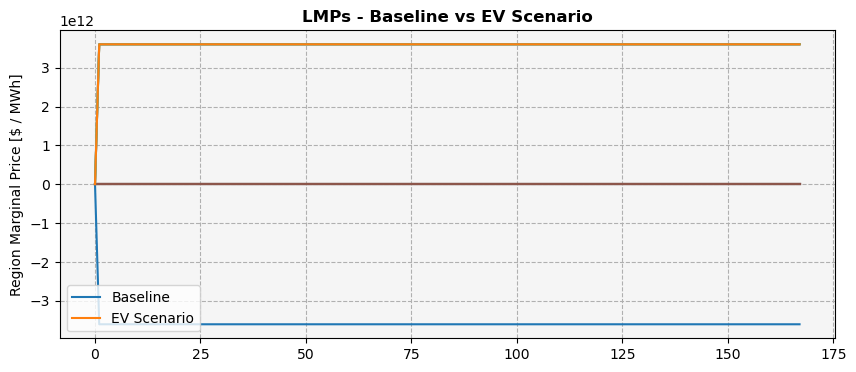

In [58]:
'''
Plotting LMPs - Comparison
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (10, 4))

# Plot baseline
_ = vis.plot_lmps(ax, baseline_solution)
ax.set_title('LMPs - Baseline vs EV Scenario', fontweight='bold')
ax.legend(['Baseline'])

# Plot EV scenario on same axes
_ = vis.plot_lmps(ax, ev_solution)
ax.legend(['Baseline', 'EV Scenario'])


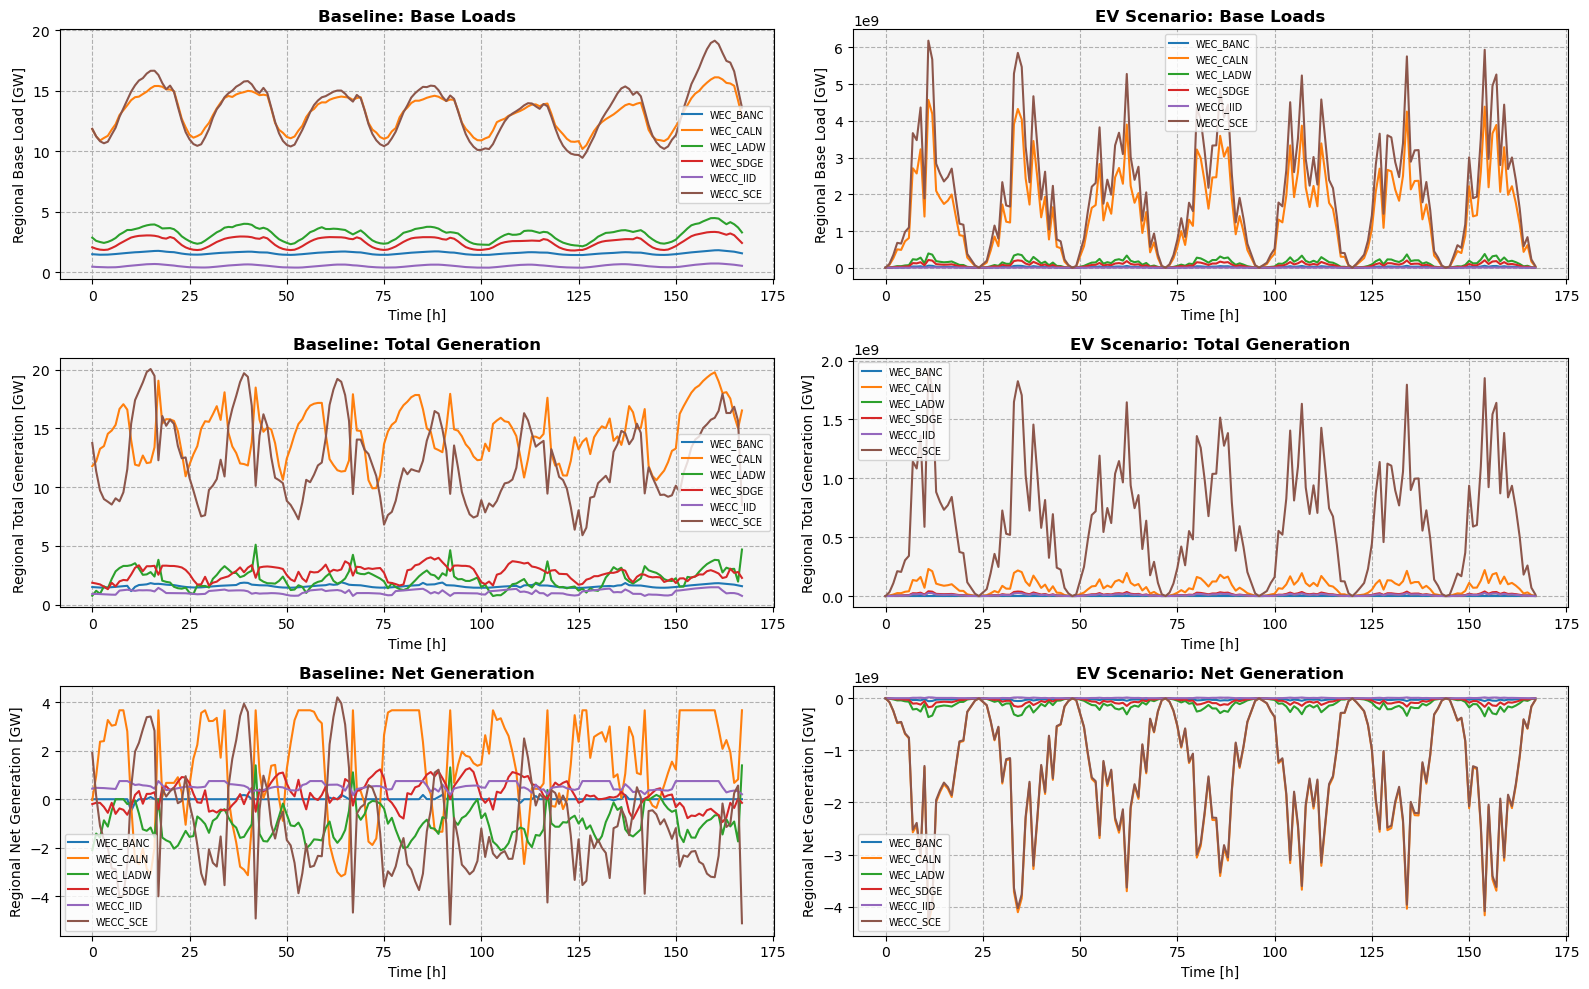

In [59]:
'''
Plotting Regional loads and generation - Comparison
'''
deep_reload(vis)

fig, ax = plt.subplots(3, 2, figsize = (16, 10))

# Baseline plots
_ = vis.plot_base_loads(ax[0, 0], baseline_solution)
ax[0, 0].set_title('Baseline: Base Loads', fontweight='bold')
_ = vis.plot_total_generation(ax[1, 0], baseline_solution)
ax[1, 0].set_title('Baseline: Total Generation', fontweight='bold')
_ = vis.plot_net_generation(ax[2, 0], baseline_solution)
ax[2, 0].set_title('Baseline: Net Generation', fontweight='bold')

# EV scenario plots
_ = vis.plot_base_loads(ax[0, 1], ev_solution)
ax[0, 1].set_title('EV Scenario: Base Loads', fontweight='bold')
_ = vis.plot_total_generation(ax[1, 1], ev_solution)
ax[1, 1].set_title('EV Scenario: Total Generation', fontweight='bold')
_ = vis.plot_net_generation(ax[2, 1], ev_solution)
ax[2, 1].set_title('EV Scenario: Net Generation', fontweight='bold')

plt.tight_layout()


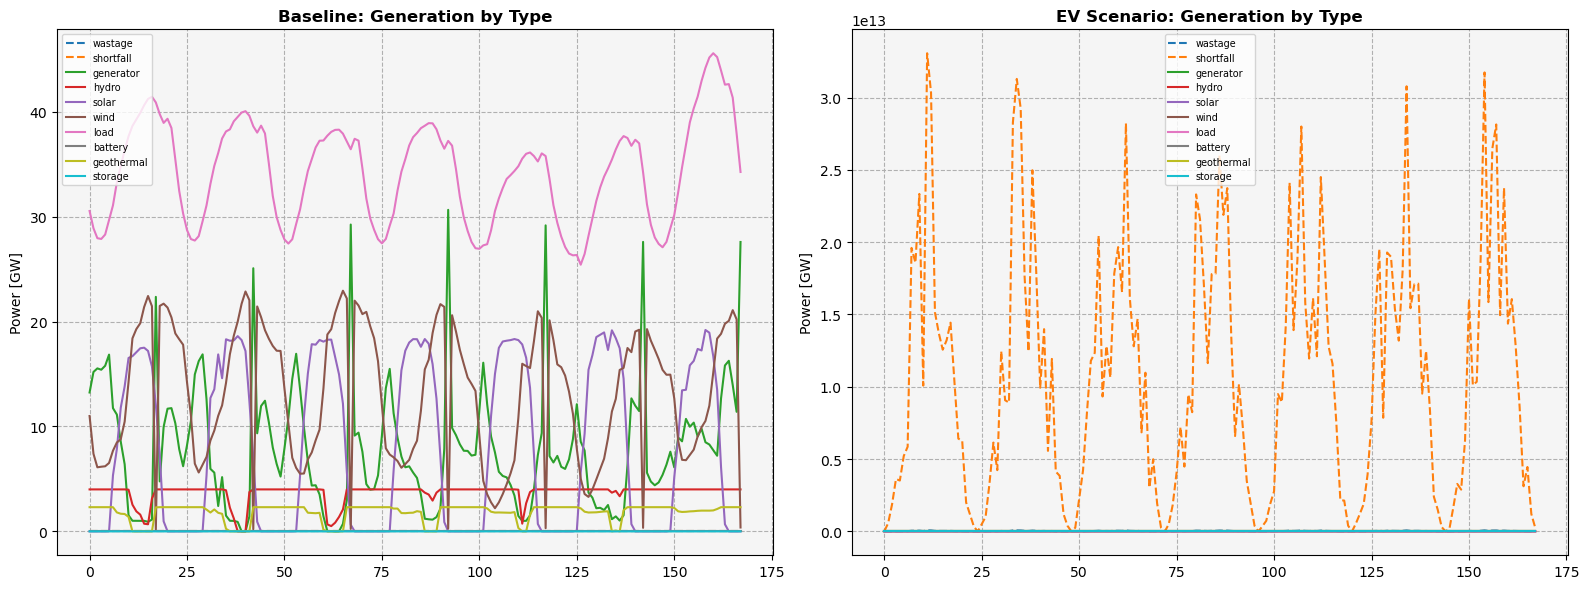

In [60]:
'''
Plotting generation by type - Comparison
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 2, figsize = (16, 6))

# Baseline
_ = vis.plot_generation_by_type(ax[0], baseline_solution)
ax[0].set_title('Baseline: Generation by Type', fontweight='bold')

# EV scenario
_ = vis.plot_generation_by_type(ax[1], ev_solution)
ax[1].set_title('EV Scenario: Generation by Type', fontweight='bold')

plt.tight_layout()


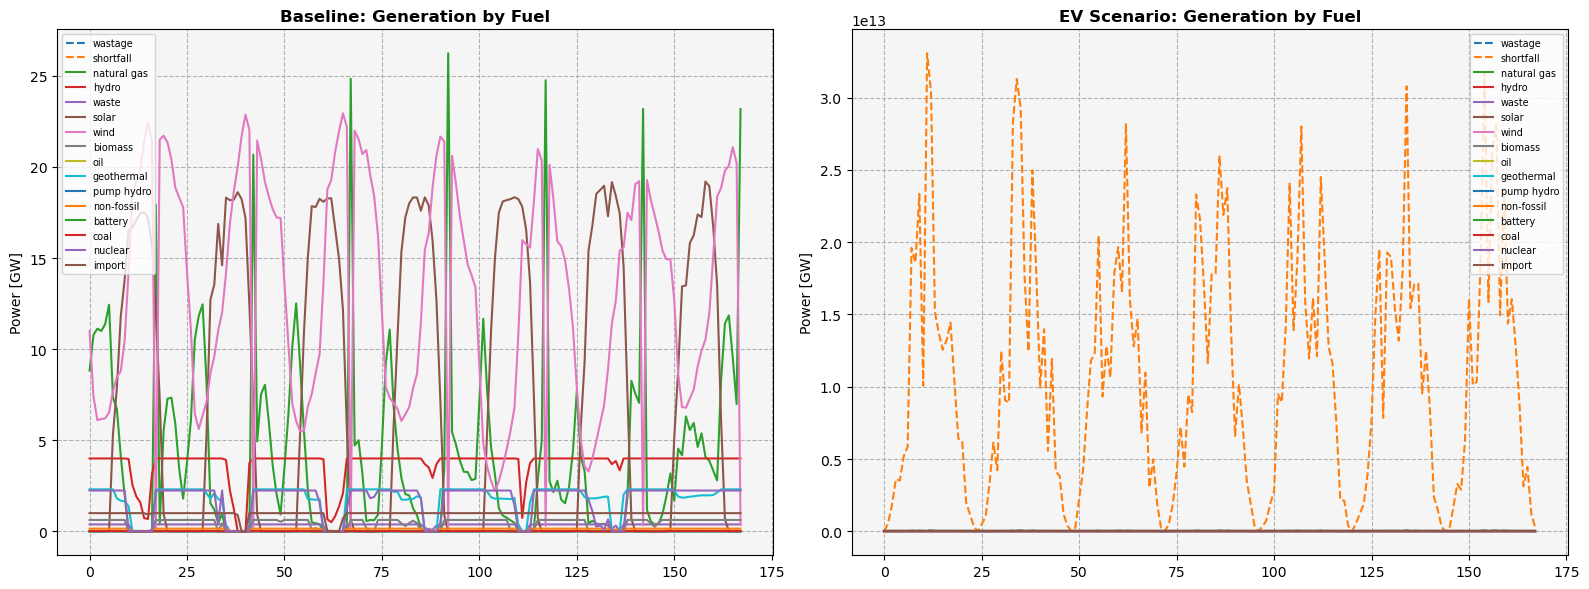

In [61]:
'''
Plotting generation by fuel - Comparison
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 2, figsize = (16, 6))

# Baseline
_ = vis.plot_generation_by_fuel(ax[0], baseline_solution)
ax[0].set_title('Baseline: Generation by Fuel', fontweight='bold')

# EV scenario
_ = vis.plot_generation_by_fuel(ax[1], ev_solution)
ax[1].set_title('EV Scenario: Generation by Fuel', fontweight='bold')

plt.tight_layout()


NameError: name 'solution' is not defined

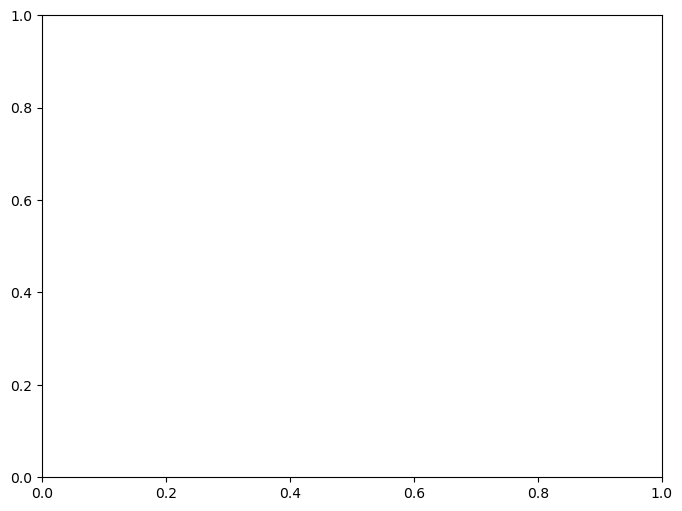

In [62]:
'''
Plotting capex by fuel
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 6))

_ = vis.plot_capex_by_type(ax, solution)

Now, let's implement custom policies

In [ ]:
'''
Loading graph and policies - with no capex
'''
deep_reload(good)

graph = good.graph.graph_from_json('Examples/California.json')

# for source, node in graph._node.items():
#     for handle, asset in node['assets'].items():

#         if asset['_class'] == 'Store':

#             asset['capex_cost'] = 0
#             print('a')

policies = {
    'california_ps':{
        '_class': 'Portfolio_Standard',
        'ratio': 0.85,
        'inclusion_criteria': {
            0: "lambda a: a.get('renewable', False)",
            1: "lambda a: a.get('_class', '') != 'Store'",
            2: "lambda a: a.get('type', '') != 'load'",
            3: "lambda a: a.get('jurisdiction', '') == 'CA'"
        },
        'exclusion_criteria': {
            0: "lambda a: not a.get('renewable', False)",
            1: "lambda a: a.get('_class', '') != 'Store'",
            2: "lambda a: a.get('type', '') != 'load'",
            3: "lambda a: a.get('jurisdiction', '') == 'CA'"
        },
    },
    'california_ct': {
        '_class': 'Capacity_Target',
        'target': 70e9,
        'inclusion_criteria': {
            0: "lambda a: a.get('renewable', False)",
            1: "lambda a: a.get('_class', '') != 'Store'",
            2: "lambda a: a.get('type', '') != 'load'",
            3: "lambda a: a.get('jurisdiction', '') == 'CA'"
        },
    },
    'california_rm' : {
        '_class': 'Reserve_Margin',
        'margin': .1,
        'sign': -1,
        'demand_criteria': {
            2: "lambda a: a.get('type', '') == 'load'",
        },
        'supply_criteria': {
            1: "lambda a: a.get('_class', '') != 'Store'",
            2: "lambda a: a.get('type', '') != 'load'",
        },
    },
}

In [ ]:
'''
Setup: Generate EV load and prepare for two scenarios
7 days = 168 hours
'''
deep_reload(good)

# Configuration
NUM_HOURS = 168  # 7 days
START_HOUR = 6 * 32 * 24  # Start from June 1st

# Generate randomized EV load (max 1GW)
print("=" * 60)
print("GENERATING EV CHARGING LOAD")
print("=" * 60)
ev_charging_load = generate_random_ev_load(num_hours=NUM_HOURS, max_peak_gw=1.0, seed=42)
print(f"EV Load Summary:")
print(f"  Time period: {NUM_HOURS} hours ({NUM_HOURS/24:.0f} days)")
print(f"  Total energy: {ev_charging_load.sum() / 1e9:.2f} GWh")
print(f"  Average hourly load: {ev_charging_load.mean() / 1e9:.2f} GW")
print(f"  Peak hourly load: {ev_charging_load.max() / 1e9:.2f} GW")

# Network configuration
kw = {
    'verbose': True,
    'steps': (START_HOUR, START_HOUR + NUM_HOURS),
    'amortization_period': 31536000,
    'shortfall_capacity': np.inf,
    'shortfall_cost': 1e3,
    'wastage_capacity': np.inf,
    'wastage_cost': 1e3,
}

# ============================================================
# SCENARIO 1: BASELINE (Base load only)
# ============================================================
print("\n" + "=" * 60)
print("SCENARIO 1: BASELINE (Base load only)")
print("=" * 60)

# Prepare baseline graph
baseline_graph = slice_graph_profiles(deepcopy(graph), start_hour=START_HOUR, num_hours=NUM_HOURS)

# Build baseline network
baseline_network = good.optimization.network.Network(**kw).from_graph(
    baseline_graph, policies)

baseline_network.build()
print("\nBaseline model size:")
baseline_network.size()


Parameters Built: 0.7711141109466553
Variables Built: 0.790550947189331
Constraints Built: 4.404662847518921
Objective Built: 0.14608287811279297


ModelSizeReport(activated = Bunch(binary_variables = 0, constraints = 201658, continuous_variables = 74263, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 74263), overall = Bunch(binary_variables = 0, constraints = 201658, continuous_variables = 74263, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 74263), warning = Bunch(unassociated_disjuncts = 0))

In [ ]:
'''
Solving the model
'''
deep_reload(good)

kw = {
    'solver': {
        '_name': 'cbc',
    },
}

network.solve(**kw)
solution = network.solution

print(f'Objective Value: {pe.value(network.model.objective)}')

Problem Solved: 320.9496810436249
Objective Value: 359435265.93392235


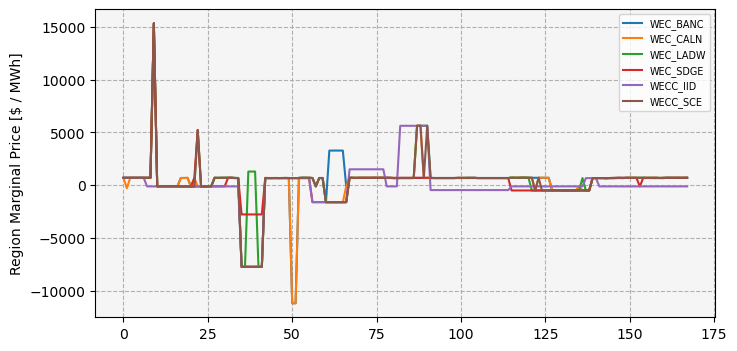

In [ ]:
'''
Plotting LMPs
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 4))

_ = vis.plot_lmps(ax, solution)

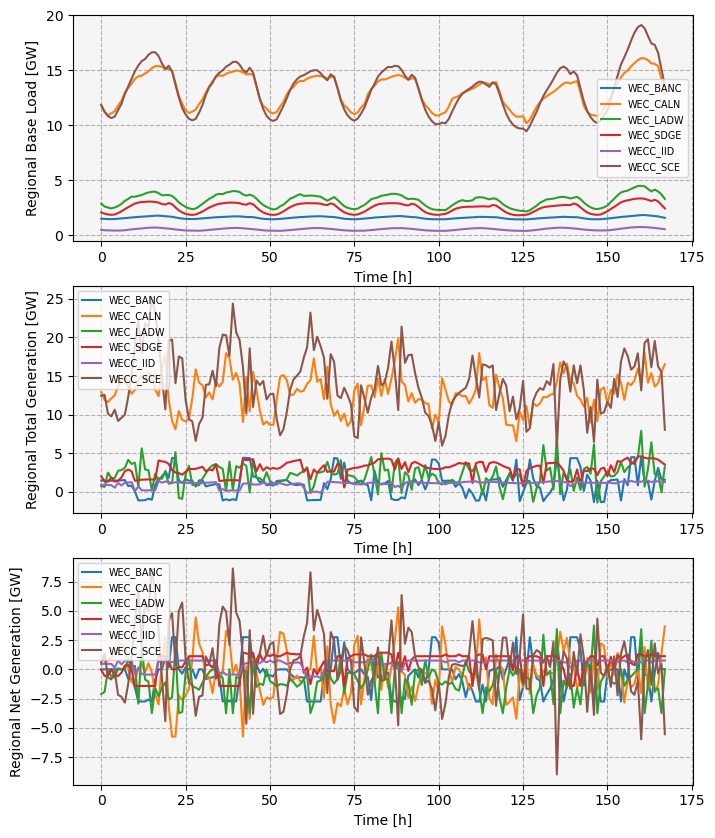

In [ ]:
'''
Plotting Regional loads and generation
'''
deep_reload(vis)

fig, ax = plt.subplots(3, 1, figsize = (8, 10))

_ = vis.plot_base_loads(ax[0], solution)
_ = vis.plot_total_generation(ax[1], solution)
_ = vis.plot_net_generation(ax[2], solution)

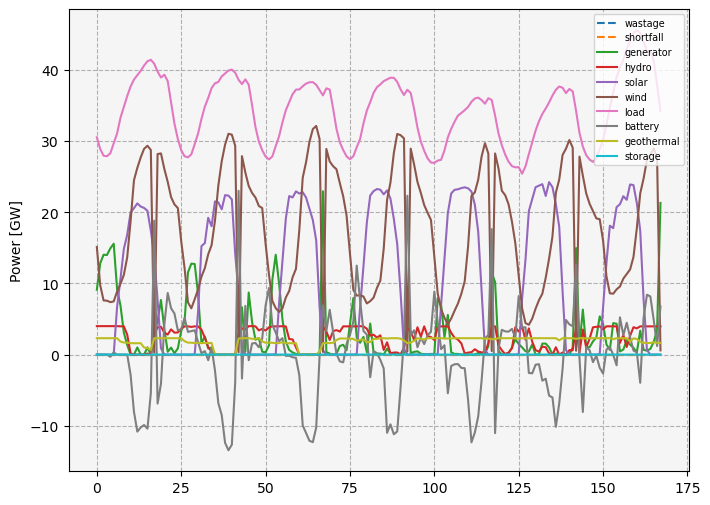

In [ ]:
'''
Plotting generation by type
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 6))

_ = vis.plot_generation_by_type(ax, solution)

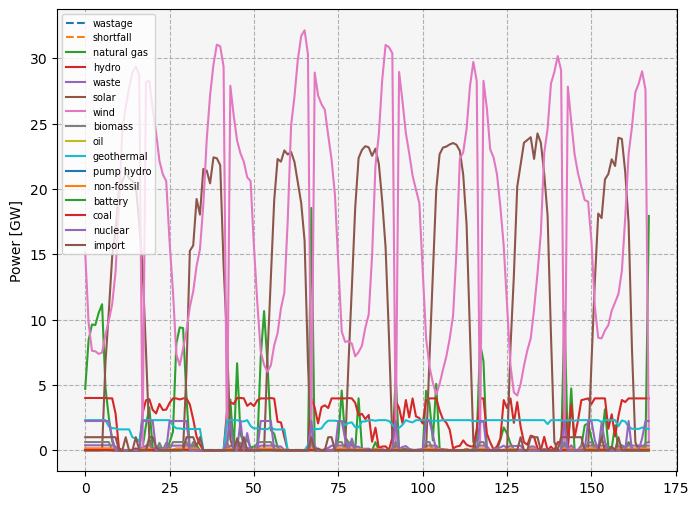

In [ ]:
'''
Plotting generation by fuel
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 6))

_ = vis.plot_generation_by_fuel(ax, solution)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


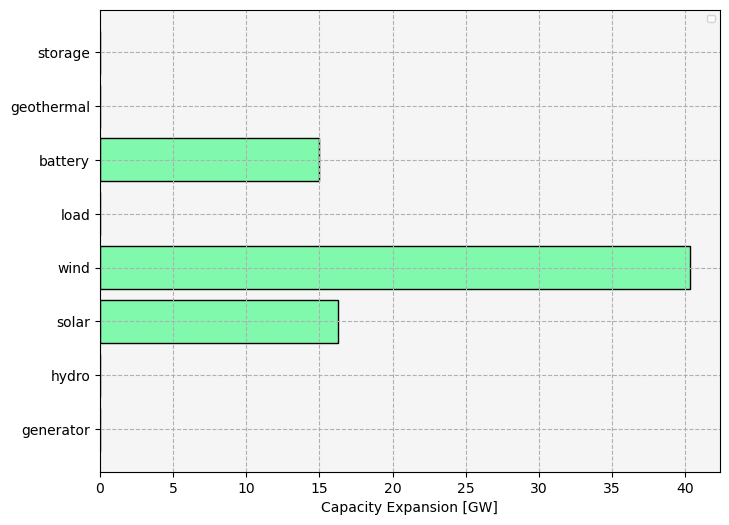

In [ ]:
'''
Plotting capex by fuel
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 6))

_ = vis.plot_capex_by_type(ax, solution)